In [21]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Introduction

In the previous notebook, we explored Principal Component Analysis (PCA) as a fundamental technique for feature extraction and dimensionality reduction. PCA allowed us to project high-dimensional data onto a lower-dimensional linear subspace, capturing the directions of maximum variance. This approach enabled us:
* to visualize complex datasets,
* compress information,
* and improve the performance of downstream machine learning tasks by alleviating the curse of dimensionality.

However, PCA has important limitations. Most notably, **it is a linear and unsupervised method**:
* it can only capture linear relationships in the data
* and does not use any information about class labels or outputs.

When the true structure of the data lies on a nonlinear manifold, or when we want to extract features that are most relevant for a supervised task, PCA may fail to reveal meaningful patterns or provide effective dimensionality reduction. Real-world datasets often exhibit complex, nonlinear relationships and may benefit from supervised feature extraction.

In this notebook, we will address these limitations by introducing both supervised and nonlinear feature extraction techniques. We will discuss methods such as Partial Least Squares (PLS) and Canonical Correlation Analysis (CCA) as supervised extensions of feature extraction, as well as kernel methods (e.g., kernel PCA) that allow us to uncover nonlinear structures in data. These approaches provide more powerful representations for visualization and learning tasks.



# 1. Supervised MVA

## 1.1 PCA is unsupervised

Remember PCA is an **unsupervised** algorithm!!!!

<img align="right" src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/ML/PCA/PCA_2.jpg" width="30%" >


Consider the example of the figure where we have a binary classification problem.
* Which direction will PCA consider as the most relevant one?
* If we had to extract only one projection, which is the most relevant for the task?
* Clearly, when dealing with supervised problems, we should consider the labels to obtain good features

**Solution**: we can find in the literature supervised feature extraction approaches, such as, Partial Least Squares (PLS), Orthogonal Partial Least Squares (OPLS) and  Canonical Correlation Analysis (CCA). These methods try to maximize either the covariance or correlation between the projected data and the labels, in this way, try to find the proyections that mostly align with the targets.


## 1.2 Partial Least Squares (PLS)

<img align="right" src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/ML/PCA/PLS.png" width="30%" >

**Goal:**  
Find linear projections of the input and output data, $\mathbf{X}$ and $\mathbf{Y}$, such that their **covariance** is maximized.

Formally, we seek pairs of projection vectors $(\mathbf{u}, \mathbf{v})$ that solve:

$$
\mathbf{u}, \mathbf{v} =
\underset{\mathbf{u}, \mathbf{v}}{\mathrm{argmax}}~
\mathrm{Cov}(\mathbf{X}\mathbf{u}, \mathbf{Y}\mathbf{v})
= \underset{\mathbf{u}, \mathbf{v}}{\mathrm{argmax}}~
\mathbf{u}^\top \mathbf{C_{XY}} \mathbf{v}
$$

subject to orthonormality constraints:

$$
\mathbf{u}^\top \mathbf{u} = \mathbf{v}^\top \mathbf{v} = 1
$$

where $\mathbf{C_{XY}} = \frac{1}{N} \mathbf{X}^\top \mathbf{Y}$ is the empirical cross-covariance matrix.


### **Solution: Derivation (one-dimensional case)**

For the first pair of latent directions $(\mathbf{u}_1, \mathbf{v}_1)$ we solve:

$$
\mathbf{u}_1, \mathbf{v}_1 =
\underset{\mathbf{u}_1, \mathbf{v}_1}{\mathrm{argmax}}~
\mathbf{u}_1^\top \mathbf{C_{XY}} \mathbf{v}_1,
\quad
\text{s.t. }~
\mathbf{u}_1^\top \mathbf{u}_1 = \mathbf{v}_1^\top \mathbf{v}_1 = 1
$$

The Lagrangian function is:

$$
\mathcal{L} =
\mathbf{u}_1^\top \mathbf{C_{XY}} \mathbf{v}_1
+ \lambda_1 (1 - \mathbf{u}_1^\top \mathbf{u}_1)
+ \gamma_1 (1 - \mathbf{v}_1^\top \mathbf{v}_1)
$$

Taking derivatives with respect to $\mathbf{u}_1$ and $\mathbf{v}_1$:

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{u}_1} =
\mathbf{C_{XY}} \mathbf{v}_1 - 2 \lambda_1 \mathbf{u}_1 = 0
\quad \Rightarrow \quad
\mathbf{C_{XY}} \mathbf{v}_1 = 2\lambda_1 \mathbf{u}_1
$$

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{v}_1} =
\mathbf{C_{XY}}^\top \mathbf{u}_1 - 2 \gamma_1 \mathbf{v}_1 = 0
\quad \Rightarrow \quad
\mathbf{C_{XY}}^\top \mathbf{u}_1 = 2\gamma_1 \mathbf{v}_1
$$

Multiplying both sides respectively by $\mathbf{C_{XY}}^\top$ and $\mathbf{C_{XY}}$ gives:

$$
\mathbf{C_{XY}}^\top \mathbf{C_{XY}} \mathbf{v}_1 = 4\lambda_1 \gamma_1 \mathbf{v}_1,
\quad
\mathbf{C_{XY}} \mathbf{C_{XY}}^\top \mathbf{u}_1 = 4\lambda_1 \gamma_1 \mathbf{u}_1
$$

These are standard **eigenvalue problems** for $\mathbf{v}_1$ and $\mathbf{u}_1$.  
The eigenvectors of $\mathbf{C_{XY}}^\top \mathbf{C_{XY}}$ and $\mathbf{C_{XY}}\mathbf{C_{XY}}^\top$
correspond to the **right and left singular vectors** of $\mathbf{C_{XY}}$.

Thus, the solution is obtained through the **Singular Value Decomposition (SVD)**:

$$
\mathbf{C_{XY}} = \mathbf{U} \, \mathbf{S} \, \mathbf{V}^\top
$$

where:
- $\mathbf{U}$: left singular vectors (directions in $X$)
- $\mathbf{V}$: right singular vectors (directions in $Y$)
- $\mathbf{S}$: singular values, proportional to the covariance captured by each pair

Each pair $(\mathbf{u}_i, \mathbf{v}_i)$ defines one latent component:
$$
\mathbf{t}_i = \mathbf{X}\mathbf{u}_i, \quad \mathbf{s}_i = \mathbf{Y}\mathbf{v}_i
$$

and $\mathrm{Cov}(\mathbf{t}_i, \mathbf{s}_i) = s_i$,  
where $s_i$ is the $i$-th singular value of $\mathbf{C_{XY}}$.


### **Comments:**

* PLS finds **directions of maximum covariance** between $X$ and $Y$.
* It treats both datasets **symmetrically**.
* The first component explains the strongest joint variation,  and subsequent components are orthogonal by construction.
* The total number of meaningful components is limited by:
  $$
  \text{rank}(\mathbf{C_{XY}}) \le \min(\text{rank}(X), \text{rank}(Y))
  $$
  When $Y$ is one-hot encoded with $C$ classes, $\text{rank}(Y) = C - 1$.
* PLS is widely used for **supervised dimensionality reduction**: by taking $Y$ as the one-hot labels, the latent space aligns with discriminative directions.




## 1.3 Canonical Correlation Analysis (CCA)

<img align="right" src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/ML/PCA/CCA.jpg" width="30%" >

**Goal:**  
Find linear projections of the input and output data, $\mathbf{X}$ and $\mathbf{Y}$, such that the resulting components are **maximally correlated**.

$$
\mathbf{u}, \mathbf{v} =
\underset{\mathbf{u}, \mathbf{v}}{\mathrm{argmax}}~
\frac{\left(\mathbf{u}^\top \mathbf{C_{XY}} \mathbf{v} \right)^2}
{\mathbf{u}^\top \mathbf{C_{XX}} \mathbf{u} ~ \mathbf{v}^\top \mathbf{C_{YY}} \mathbf{v}}
$$

For multiple components ($K>1$), this is reformulated as:

$$
\begin{array}{rl}
\mathbf{U}, \mathbf{V} = &
\underset{\mathbf{U}, \mathbf{V}}{\mathrm{argmax}}~
\mathrm{Tr}\left\{\mathbf{U}^\top \mathbf{C_{XY}} \mathbf{V}\right\} \\
\text{s.t.} &
\mathbf{U}^\top \mathbf{C_{XX}} \mathbf{U} =
\mathbf{V}^\top \mathbf{C_{YY}} \mathbf{V} = \mathbf{I}
\end{array}
$$


### **Solution**

This optimization problem can be solved as a **generalized eigenvalue problem**.

To see this, consider the one-dimensional case ($K = 1$):

$$
\mathbf{u}_1, \mathbf{v}_1 =
\underset{\mathbf{u}_1, \mathbf{v}_1}{\mathrm{argmax}}~
\mathbf{u}_1^\top \mathbf{C_{XY}} \mathbf{v}_1,
\quad
\text{s.t. }~
\mathbf{u}_1^\top \mathbf{C_{XX}} \mathbf{u}_1 =
\mathbf{v}_1^\top \mathbf{C_{YY}} \mathbf{v}_1 = 1
$$

Applying the Lagrange multiplier method:

$$
\mathcal{L} =
\mathbf{u}_1^\top \mathbf{C_{XY}} \mathbf{v}_1
+ \lambda_1(1 - \mathbf{u}_1^\top \mathbf{C_{XX}} \mathbf{u}_1)
+ \gamma_1(1 - \mathbf{v}_1^\top \mathbf{C_{YY}} \mathbf{v}_1)
$$

Taking derivatives and setting them to zero leads to the pair of coupled equations:

$$
\mathbf{C_{XY}} \mathbf{v}_1 = \lambda_1 \mathbf{C_{XX}} \mathbf{u}_1, \qquad
\mathbf{C_{XY}}^\top \mathbf{u}_1 = \gamma_1 \mathbf{C_{YY}} \mathbf{v}_1
$$

Multiplying by $\mathbf{C_{XX}}^{-1}$ and $\mathbf{C_{YY}}^{-1}$, respectively, converts them into two **standard eigenvalue problems**. The eigenvectors corresponding to the largest eigenvalues define the first pair of canonical directions $(\mathbf{u}_1, \mathbf{v}_1)$. Subsequent components are obtained by enforcing orthogonality constraints.



### **Comments:**

* Computing $\mathbf{C_{XX}}^{-1}$ and $\mathbf{C_{YY}}^{-1}$ can be **numerically unstable** if $X$ or $Y$   contain redundant or highly collinear variables.  
  Common solutions include:
  - Adding a small **regularization** term (ridge-type):  
    $\mathbf{C_{XX}} + \epsilon \mathbf{I}$, $\mathbf{C_{YY}} + \epsilon \mathbf{I}$
  - Using **PCA pre-whitening** before applying CCA.

* The **maximum number of meaningful canonical components** is  $\min(\mathrm{rank}(X), \mathrm{rank}(Y))$. When $Y$ represents one-hot encoded class labels, this rank is $n_{\text{classes}} - 1$.

* CCA is typically used to project both $X$ and $Y$ into a **shared latent space** where their correlation is maximized.  This makes it very useful for **multimodal analysis** (e.g., audio–visual, brain–behavior).

* In **classification tasks**, using the one-hot encoding of the labels as $Y$, the canonical components of $X$ define a **discriminant subspace** that often outperforms PLS in terms of class separability.






### **Connection PLS-CCA**

PLS and CCA share the same underlying idea: to find projections of $X$ and $Y$ that are most strongly related.

| Aspect | PLS | CCA |
|:--------|:----|:----|
| Objective | Maximize covariance | Maximize correlation |
| Normalization | None | Whiten $X$ and $Y$ |
| Optimization | SVD of $\mathbf{C_{XY}}$ | Generalized eigenvalue problem |
| Symmetry | Symmetric | Symmetric |
| Result | Unscaled shared subspace | Whitened, correlation-maximized subspace |

Both methods produce paired latent variables $(\mathbf{t}_i, \mathbf{s}_i)$, but CCA explicitly normalizes them to have unit variance, while PLS retains their original scaling.


## 1.4 Sklearn implementations for PLS and CCA

In *scikit-learn*, both **Partial Least Squares (PLS)** and **Canonical Correlation Analysis (CCA)** are implemented under the module `sklearn.cross_decomposition`.

All of these models extract pairs of latent variables
$(t_i = X w_i, ~ u_i = Y c_i)$ that capture the shared structure between $X$ and $Y$, but they differ in what quantity they **maximize** and how they treat both datasets.



### Overview of the main implementations

| Method | Objective | Symmetry | Criterion | Iterative | Whitening | `predict` | Typical use |
|:--------|:-----------|:----------|:-----------|:------------|:------------|:-------------|:--------------|
| **`PLSSVD`** | Maximize covariance | ✅ Symmetric | $\max~\mathrm{Cov}(Xw, Yc)$ | ❌ No | ❌ No | ❌ | Fast, exploratory linkage |
| **`PLSCanonical`** | Maximize correlation | ✅ Symmetric | $\max~\mathrm{Corr}(Xw, Yc)$ | ✅ Yes | ❌ No | ❌ | Canonical-style, symmetric analysis |
| **`PLSRegression`** | Predict $Y$ from $X$ | ❌ Asymmetric | $\min~\|Y - X B\|^2$ | ✅ Yes | ❌ No | ✅ | Supervised regression tasks |
| **`CCA`** | Maximize correlation | ✅ Symmetric | $\max~\mathrm{Corr}(Xw, Yc)$ | ❌ No | ✅ Yes | ❌ | Classical correlation analysis |


###  Key differences

- **PLSSVD** performs a *single SVD* on the cross-covariance matrix $X^\top Y$, it is purely algebraic and non-iterative, ideal for exploratory or fast analysis.

- **PLSCanonical** applies *deflation* after each component and ensures orthogonality,  approximating the behaviour of CCA but without whitening.

- **PLSRegression** adds a regression step to predict $Y$ from $X$, producing a matrix of regression coefficients $B$ such that $\hat{Y} = X B$.

- **CCA** explicitly *whitens* both $X$ and $Y$ (normalizes variance to 1)  before maximizing correlation between projections.  
  It is the most “pure” version of canonical correlation.


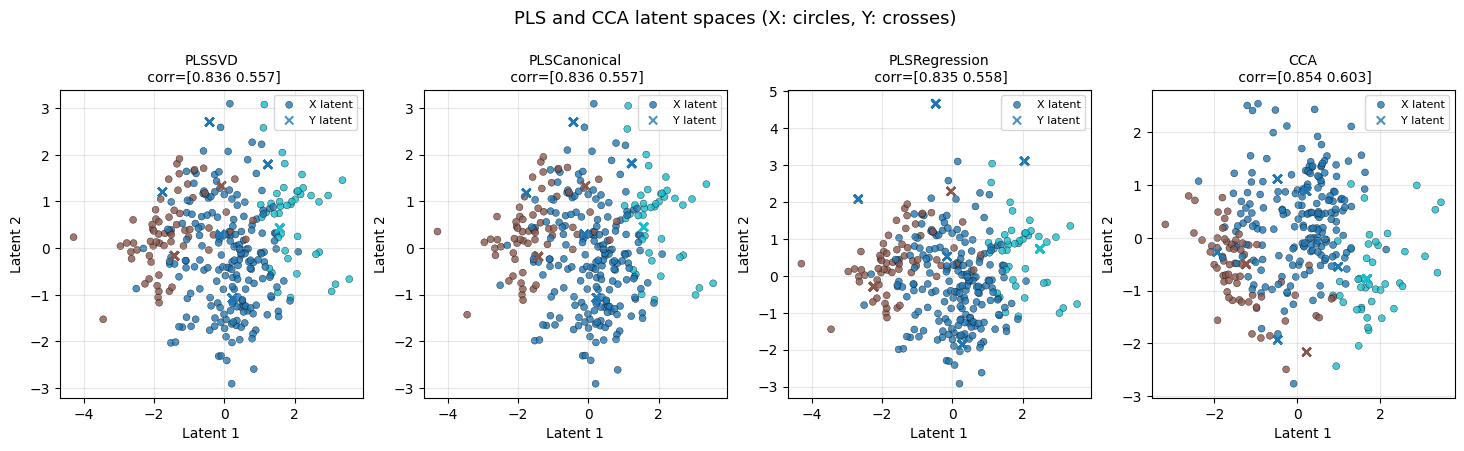

In [22]:
# === Extended visualization: PLS and CCA comparison with X and Y latent projections ===
from sklearn.cross_decomposition import PLSSVD, PLSCanonical, PLSRegression, CCA
from sklearn.datasets import make_multilabel_classification
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# --- Generate synthetic correlated data ---
X, Y = make_multilabel_classification(
    n_samples=300, n_features=6, n_classes=3, n_labels=1, random_state=0
)
y = np.argmax(Y, axis=1)  # class labels for coloring
X = StandardScaler().fit_transform(X)
Y = StandardScaler().fit_transform(Y)

methods = {
    "PLSSVD": PLSSVD(n_components=2),
    "PLSCanonical": PLSCanonical(n_components=2),
    "PLSRegression": PLSRegression(n_components=2),
    "CCA": CCA(n_components=2)
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
correlations = {}

for ax, (name, model) in zip(axes, methods.items()):
    model.fit(X, Y)
    X_lat, Y_lat = model.transform(X, Y)

    # Compute correlation between latent pairs
    corr = [np.corrcoef(X_lat[:, i], Y_lat[:, i])[0, 1] for i in range(X_lat.shape[1])]
    correlations[name] = corr

    # Plot latent projections for X and Y
    scatter_x = ax.scatter(
        X_lat[:, 0], X_lat[:, 1],
        c=y, cmap="tab10",
        s=25, alpha=0.8, edgecolor="k", linewidth=0.3,
        marker="o", label="X latent"
    )
    scatter_y = ax.scatter(
        Y_lat[:, 0], Y_lat[:, 1],
        c=y, cmap="tab10",
        s=35, alpha=0.8, marker="x", label="Y latent"
    )

    ax.set_title(f"{name}\n corr={np.round(corr, 3)}", fontsize=10)
    ax.set_xlabel("Latent 1")
    ax.set_ylabel("Latent 2")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")

# Add colorbar
#cbar = fig.colorbar(scatter_x, ax=axes, orientation="horizontal",
#                    fraction=0.04, pad=0.1, label="Class label")

plt.suptitle("PLS and CCA latent spaces (X: circles, Y: crosses)", y=1.08, fontsize=13)
#plt.tight_layout()
plt.show()


# 2. Performance evaluation of supervised feature extraction: PLS, CCA

In this section, we are going to analyze the advantages of using supervised the above feature extraction techniques.

In [23]:
import torch
from torchvision import datasets, transforms

# Define transformations
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST dataset normalization
])

# Cargar el dataset MNIST
mnist_raw = datasets.MNIST(root='.', train=True, download=True, transform=mnist_transform)

# Obtener todas las imágenes y etiquetas
X  = torch.stack([mnist_raw[i][0].view(-1) for i in range(len(mnist_raw))]).numpy()
Y  = mnist_raw.targets.numpy()

In [24]:
import numpy as np
from sklearn.calibration import label_binarize
from sklearn.model_selection import train_test_split

h, w = 28, 28                                    # MNIST image dimensions

n_samples = X.shape[0]

n_features = X.shape[1]
n_classes = np.unique(Y).shape[0]

print('Dataset size information:')
print('n_features: %d' % n_features)
print('n_classes: %d' % n_classes)
print('Global absolute mean (should be ~0):', float(np.mean(X)))

###############################################################################
# Data preparation
np.random.seed(1)

# Train/test split (stratified)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=1, stratify=Y
)

# Subsample only max_samples training samples for speed
max_samples = 5000
if X_train.shape[0] > max_samples:
    idx = np.random.choice(X_train.shape[0], max_samples, replace=False)
    X_train = X_train[idx]
    Y_train = Y_train[idx]

# Binarize the labels for supervised feature extraction methods
set_classes = np.unique(Y_train)
Y_train_bin = label_binarize(Y_train, classes=set_classes)
Y_test_bin = label_binarize(Y_test, classes=set_classes)

# Note: we already centered to zero mean globally; avoid re-scaling again here
print('Number of training samples: %d' % X_train.shape[0])
print('Number of test samples: %d' % X_test.shape[0])

Dataset size information:
n_features: 784
n_classes: 10
Global absolute mean (should be ~0): -0.00012829367187805474
Number of training samples: 5000
Number of test samples: 15000


 Note: By using one-hot labels as \(Y\), the method finds the directions in \(X\)
that are maximally covariant with the target classes, producing a **low-dimensional, supervised feature extraction**.

We will then evaluate how well these components separate the classes using a KNN classifier.

## 2.1. Evaluation of Partial Least Squares (PLS)

Let's start computing the PLS approach with the method [`PLSSVD( )`](http://scikit-learn.org/stable/modules/generated/sklearn.cross_decomposition.PLSSVD.html) and then we will:
1. Obtain the first eigenvectors from the training data and obtain the projections of training, validation and test data. Note that in this case we  can only obtain as many new projections as number of categories.
2. Compute the SVM accuracy provided by the maximum number of extracted features.

Note: to work with the supervised feature extraction methods, we have to use the binarized label vector (`Y_train_bin`); whereas, to train the linear SVM we can go on using the standard label codification (`Y_train`)

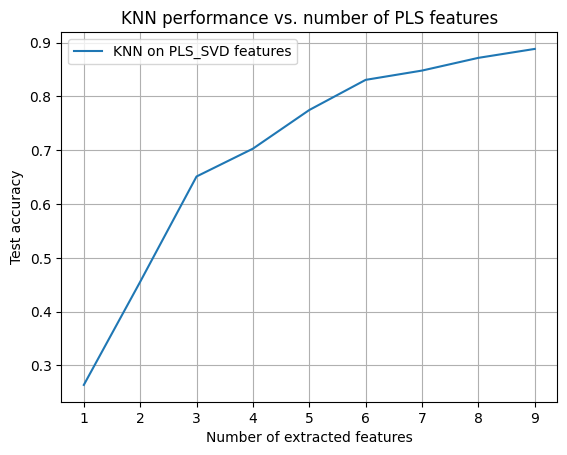

In [25]:
from sklearn.cross_decomposition import PLSSVD
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

N_feat_max = n_classes - 1  # As many new features as classes minus 1
acc_knn = []
acc_pls = []

# Efficient: Fit PLS once with max components, then slice projections
pls = PLSSVD(n_components=N_feat_max)
pls.fit(X_train, Y_train_bin)
P_train_pls = pls.transform(X_train)
P_test_pls = pls.transform(X_test)

# 1. Evaluate performance for different number of extracted features
for k in range(1, N_feat_max + 1):
    # Use only the first k features
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(P_train_pls[:, :k], Y_train)
    acc_knn.append(knn.score(P_test_pls[:, :k], Y_test))

    # For reference, you can also compute SVM or other classifiers here
    # acc_pls.append(svm.score(P_test_pls[:, :k], Y_test))

plt.figure()
plt.plot(range(1, N_feat_max + 1), acc_knn, label='KNN on PLS_SVD features')
plt.xlabel('Number of extracted features')
plt.ylabel('Test accuracy')
plt.title('KNN performance vs. number of PLS features')
plt.legend()
plt.grid()
plt.show()



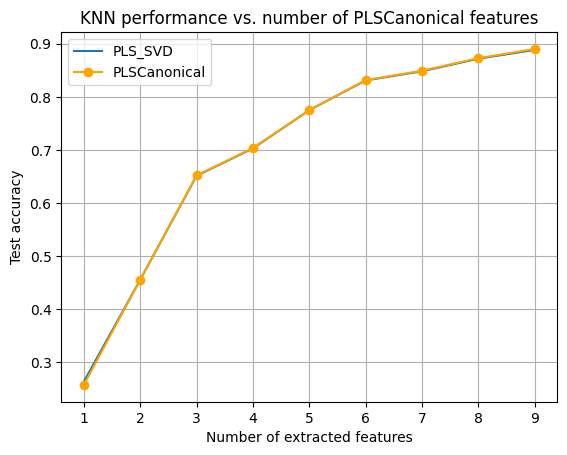

In [26]:
# --- PLSCanonical: symmetric, correlation-based formulation ---
from sklearn.cross_decomposition import PLSCanonical
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import numpy as np

# One-hot encoding
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
Y_train_bin = enc.fit_transform(np.asarray(Y_train).reshape(-1, 1))
Y_test_bin  = enc.transform(np.asarray(Y_test).reshape(-1, 1))

N_feat_max = n_classes - 1
acc_knn_plscan = []

pls_can = PLSCanonical(n_components=N_feat_max)
pls_can.fit(X_train, Y_train_bin)

# transform() returns (X_scores, Y_scores)
P_train_can, _ = pls_can.transform(X_train, Y_train_bin)
P_test_can, _  = pls_can.transform(X_test,  Y_test_bin)

for k in range(1, N_feat_max + 1):
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(P_train_can[:, :k], Y_train)
    acc_knn_plscan.append(knn.score(P_test_can[:, :k], Y_test))

plt.figure()
plt.plot(range(1, N_feat_max + 1), acc_knn, label='PLS_SVD')
plt.plot(range(1, N_feat_max + 1), acc_knn_plscan, marker='o', color='orange', label='PLSCanonical')
plt.xlabel('Number of extracted features')
plt.ylabel('Test accuracy')
plt.title('KNN performance vs. number of PLSCanonical features')
plt.legend()
plt.grid(True)
plt.show()


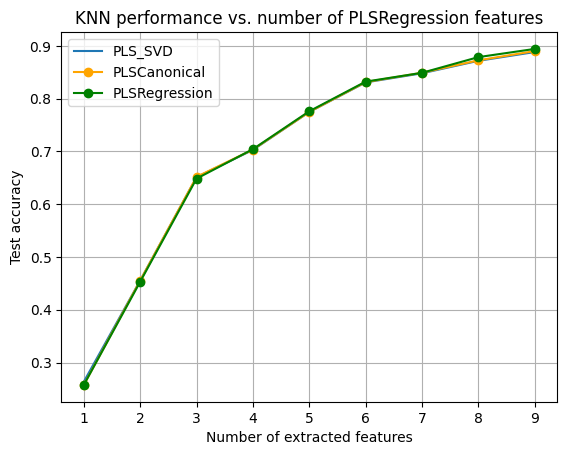

In [27]:
# --- PLSRegression: asymmetric, predictive formulation ---
from sklearn.cross_decomposition import PLSRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import numpy as np

# One-hot encoding
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
Y_train_bin = enc.fit_transform(np.asarray(Y_train).reshape(-1, 1))
Y_test_bin  = enc.transform(np.asarray(Y_test).reshape(-1, 1))

N_feat_max = n_classes - 1
acc_knn_plsreg = []

pls_reg = PLSRegression(n_components=N_feat_max)
pls_reg.fit(X_train, Y_train_bin)

# transform() returns X_scores directly
P_train_reg = pls_reg.transform(X_train)
P_test_reg  = pls_reg.transform(X_test)

for k in range(1, N_feat_max + 1):
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(P_train_reg[:, :k], Y_train)
    acc_knn_plsreg.append(knn.score(P_test_reg[:, :k], Y_test))

plt.figure()
plt.plot(range(1, N_feat_max + 1), acc_knn, label='PLS_SVD')
plt.plot(range(1, N_feat_max + 1), acc_knn_plscan, marker='o', color='orange', label='PLSCanonical')
plt.plot(range(1, N_feat_max + 1), acc_knn_plsreg, marker='o', color='green', label='PLSRegression')
plt.xlabel('Number of extracted features')
plt.ylabel('Test accuracy')
plt.title('KNN performance vs. number of PLSRegression features')
plt.legend()
plt.grid(True)
plt.show()


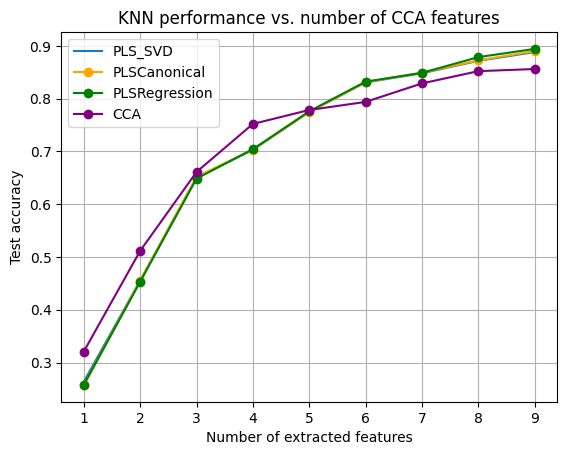

In [28]:
# --- CCA: canonical correlation analysis (symmetric, correlation-maximizing) ---
from sklearn.cross_decomposition import CCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import numpy as np

# One-hot encoding (coherente con las otras celdas)
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
Y_train_bin = enc.fit_transform(np.asarray(Y_train).reshape(-1, 1))
Y_test_bin  = enc.transform(np.asarray(Y_test).reshape(-1, 1))

# CCA no puede tener más componentes que el mínimo de estas cantidades
N_feat_max = n_classes - 1
cca_cap = min(
    N_feat_max,
    X_train.shape[1],
    Y_train_bin.shape[1],
    X_train.shape[0] - 1  # rango máximo por número de muestras
)
acc_knn_cca = []

cca = CCA(n_components=cca_cap, max_iter=500, tol=1e-06)
cca.fit(X_train, Y_train_bin)

# transform() devuelve (X_scores, Y_scores); usamos X_scores como features
X_train_lat, _ = cca.transform(X_train, Y_train_bin)
X_test_lat,  _ = cca.transform(X_test,  Y_test_bin)

# Si por estabilidad CCA devuelve menos columnas, actualizamos el rango
n_lat = X_train_lat.shape[1]
k_max = min(N_feat_max, n_lat)

for k in range(1, k_max + 1):
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_lat[:, :k], Y_train)
    acc_knn_cca.append(knn.score(X_test_lat[:, :k], Y_test))

plt.figure()
plt.plot(range(1, N_feat_max + 1), acc_knn, label='PLS_SVD')
plt.plot(range(1, N_feat_max + 1), acc_knn_plscan, marker='o', color='orange', label='PLSCanonical')
plt.plot(range(1, N_feat_max + 1), acc_knn_plsreg, marker='o', color='green', label='PLSRegression')
plt.plot(range(1, k_max + 1), acc_knn_cca, marker='o', color='purple', label='CCA')
plt.xlabel('Number of extracted features')
plt.ylabel('Test accuracy')
plt.title('KNN performance vs. number of CCA features')
plt.legend()
plt.grid(True)
plt.show()


## Exercise
Combine this FE (either PLS or CCA) with the SVM classifier into a 5 fold CV to select the optimum number of extracted features and select the parameter `C` of the classifier. Think about the most efficient and fair (avoiding overfitting effects) implementation.


### Solution 1 (leakage)

This implementation suffers from leakage. It is **not a valid solution**, but a commmon implementation

The number of selected features is 8
The optimum test accuracy is  85.51%


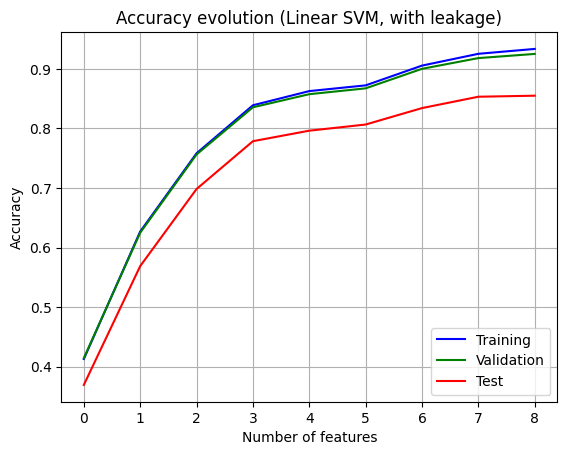

In [29]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# 1. Obtain CCA projections
cca = CCA(n_components=N_feat_max)
cca.fit(X_train, Y_train_bin)
P_train_cca = cca.transform(X_train)
P_test_cca = cca.transform(X_test)

# 2. Compute Linear SVM performance
svm = SVC(kernel='linear')
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(svm, param_grid, cv=5)

range_k = np.arange(N_feat_max)
acc_val = np.zeros((len(range_k),))
acc_train = np.zeros((len(range_k),))
acc_test = np.zeros((len(range_k),))

for i, k in enumerate(range_k):
    # CV with GridSearchCV over C
    grid.fit(P_train_cca[:, :k+1], Y_train)

    # Scores
    acc_train[k] = grid.score(P_train_cca[:, :k+1], Y_train)
    acc_test[k] = grid.score(P_test_cca[:, :k+1], Y_test)
    acc_val[k] = grid.best_score_

# Select optimum points
pos_val = np.argmax(acc_val)
print('The number of selected features is %d' % (range_k[pos_val]))
test_acc_opt = acc_test[pos_val]
print("The optimum test accuracy is  %2.2f%%" % (100 * test_acc_opt))

plt.figure()
plt.plot(acc_train, "b", label="train")
plt.plot(acc_val, "g", label="validation")
plt.plot(acc_test, "r", label="test")
plt.xlabel("Number of features")
plt.ylabel("Accuracy")
plt.title('Accuracy evolution (Linear SVM, with leakage)')
plt.legend(['Training', 'Validation', 'Test'], loc=4)
plt.grid()
plt.show()




**Note on leakage in Solution 1:**
The previous solution ("Solution 1") suffers from data leakage because the feature extraction (CCA) is fitted using both the training and validation data together (`X_train2`, `Y_train2`). This means that information from the validation set is used to learn the transformation, which can lead to overly optimistic validation and test results. In a correct cross-validation setup, the feature extraction method should be fitted only on the training folds within each CV split, and the validation/test data should remain completely unseen until evaluation. Always ensure that all preprocessing and feature extraction steps are included inside the cross-validation loop to avoid leakage.

### Solution 2

Number optimum of features: 9
Best C for this number of features: 1
The optimum test accuracy is 84.11%


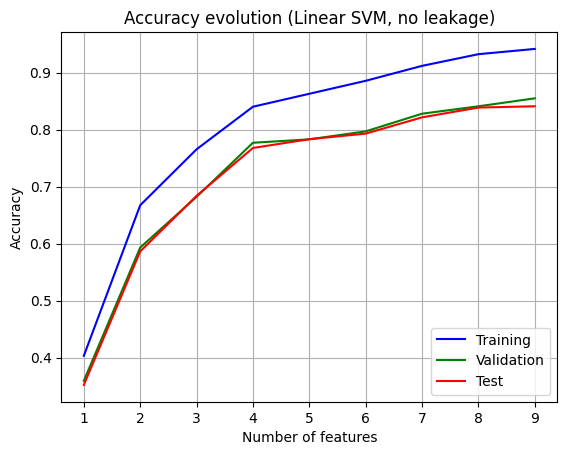

In [30]:
# Solution 2: Proper validation split and no leakage
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import CCA
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# Generate a validation split from the training data
X_train_sub, X_val, Y_train_sub, Y_val, Y_train_bin_sub, Y_val_bin = train_test_split(
    X_train, Y_train, Y_train_bin, test_size=0.2, random_state=42, stratify=Y_train)

N_feat_max = n_classes - 1  # As many new features as classes minus 1

# 1. Obtain CCA projections (fit only on training subset)
cca = CCA(n_components=N_feat_max)
cca.fit(X_train_sub, Y_train_bin_sub)
P_train_cca = cca.transform(X_train_sub)
P_val_cca   = cca.transform(X_val)
P_test_cca  = cca.transform(X_test)

# 2. Compute and plot accuracy evolution with Linear SVM
from sklearn.svm import SVC

C_values = [0.01, 0.1, 1, 10, 100]

acc_tr   = np.zeros(N_feat_max)
acc_val  = np.zeros(N_feat_max)
acc_test = np.zeros(N_feat_max)
best_C   = np.zeros(N_feat_max)

for ik, k in enumerate(range(1, N_feat_max + 1)):
    acc_tr_C   = np.zeros(len(C_values))
    acc_val_C  = np.zeros(len(C_values))
    acc_test_C = np.zeros(len(C_values))

    for iC, C in enumerate(C_values):
        svm = SVC(kernel='linear', C=C)
        svm.fit(P_train_cca[:, :k], Y_train_sub)

        acc_tr_C[iC]   = svm.score(P_train_cca[:, :k], Y_train_sub)
        acc_val_C[iC]  = svm.score(P_val_cca[:, :k],   Y_val)
        acc_test_C[iC] = svm.score(P_test_cca[:, :k],  Y_test)

    # Select best C (for this k, the best validation acc)
    idx_best_C = np.argmax(acc_val_C)
    acc_tr[ik]   = acc_tr_C[idx_best_C]
    acc_val[ik]  = acc_val_C[idx_best_C]
    acc_test[ik] = acc_test_C[idx_best_C]
    best_C[ik]   = C_values[idx_best_C]

# 3. Select best N features (check validation results)
idx_best_k   = np.argmax(acc_val)
num_opt_feat = idx_best_k + 1
test_acc_opt = acc_test[idx_best_k]
C_opt        = best_C[idx_best_k]

print('Number optimum of features: %d' % num_opt_feat)
print('Best C for this number of features: %g' % C_opt)
print("The optimum test accuracy is %2.2f%%" % (100 * test_acc_opt))

# Plot
plt.figure()
plt.plot(range(1, N_feat_max+1), acc_tr, "b", label="train")
plt.plot(range(1, N_feat_max+1), acc_val, "g", label="validation")
plt.plot(range(1, N_feat_max+1), acc_test, "r", label="test")
plt.xlabel("Number of features")
plt.ylabel("Accuracy")
plt.title('Accuracy evolution (Linear SVM, no leakage)')
plt.legend(['Training', 'Validation', 'Test'], loc=4)
plt.grid()
plt.show()


# 3. Kernel Multivariate Analysis


## 3.1 Motivation of KMVA

Previous MVA models are **linear** methods, so they are simple, easy to understand, robust to overfitting problems. However, they lack expressive power.

<img src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/ML/PCA/Linear.jpg" width="60%">

**Solution**: no linear extension by means of kernel methods!!!



## 3.2 Kernel methods: review

* Idea: Project data onto a another space (usually with a dimensionality larger than that of the original space)

<img src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/ML/PCA/kernel.jpg" width="60%">

... and run a linear algorithm run in this *feature space*. The outcome of the linear model in *feature space* turns out to be a non-linear model in the original input space.

Some useful results:

* **Kernel Trick**: It is possible to compute inner products in many $\infty$-dimensional space:
$$ k\left( {\bf x}, {\bf y}\right) = \left\langle \boldsymbol \phi({\bf x}), \boldsymbol \phi({\bf y}) \right\rangle $$
So, if a linear algorithm can be reformulated in terms of inner products, we can replace these dot products by kernel functions.
* **Representer Theorem**:  states that the solutions of certain optimization problems can be written as a linear combination of the training samples
$$ {\bf u} = \sum_{n=1}^N a^{(n)} \boldsymbol \phi({\bf x}^{(n)}) = \Phi {\bf a}$$
where the vector ${\bf a} = \left[ a^{(1)}, \ldots, a^{(N)} \right]^\top$ contains the dual variables which are indicating the weight that takes each data to represent the solution and $\boldsymbol \Phi  =  \left[ \boldsymbol  \phi({\bf x})^{(1)}, \ldots,\boldsymbol \phi({\bf x})^{(N)} \right]$ is a matrix with the data mapped in the feature space, one column per data instance.

## 3.3 Kernel Principal Component Analysis (KPCA): formulation

KPCA aims to find the projections that maximize the variance of the data in  **feature space**. This means to perform the PCA algorithm with matrix $\boldsymbol \Phi$:

###  Obtain the eigen spectrum of the covariance matrix in Feature Space $\boldsymbol \Sigma$.



- **Eigenvalue Problem**

$$ \boldsymbol \Sigma \mathbf u = \lambda \mathbf u \Rightarrow \frac{1}{N}\boldsymbol \Phi \boldsymbol \Phi^\top \mathbf u = \lambda \mathbf u $$

- **Eigenvectors are linear combinations of the data samples**:

$$
\mathbf u = \boldsymbol \Phi \mathbf a
$$

$$\frac{1}{N}\boldsymbol \Phi \boldsymbol \Phi^\top \boldsymbol \Phi \mathbf a = \lambda \boldsymbol \Phi \mathbf a $$

- Multiply the above equation by $\boldsymbol \Phi^\top$

$$ \frac{1}{N} \boldsymbol \Phi^\top \boldsymbol \Phi \boldsymbol \Phi^\top \boldsymbol \Phi \mathbf a = \lambda  \boldsymbol \Phi^\top \boldsymbol \Phi \mathbf a $$

- Remember the kernel matrix can be written as $K=\boldsymbol \Phi^\top \boldsymbol \Phi$

$$ \frac{1}{N}\bf K^2\mathbf a = \lambda \bf K \mathbf a $$

- Multiplication by $\bf K^{-1}$

$$ \frac{1}{N} \bf K \mathbf a = \lambda \mathbf a $$



The previous result states that if $\mathbf u$ is an eigenvector of the covariance matrix in feature space, $\boldsymbol \Sigma$, then $\mathbf a$, the vector with the dual coefficients of $\mathbf u$ in terms of the data samples, is an eigenvector of $\bf K$.

Moreover, if $\lambda$ is the eigenvalue of associated to $\mathbf u$, then $N\lambda$ is the eigenvalue that corresponds to $\mathbf a$.

This leads to the following **algorithm to compute the KPCA**


- **Input:** $\bf K$, kernel matrix

- **Process:**
    1. **Center** the kernel $\bf K \leftarrow \bf K - \frac{1}{N} \bf K \mathbf 1 \mathbf 1^\top - \frac{1}{N} \mathbf 1 \mathbf 1^\top \bf K + \frac{1}{N^2}  \mathbf 1 \mathbf 1^\top \bf K  \mathbf 1 \mathbf 1^\top$
    
    2. $\bf A, \Lambda$ = eig($\bf K$)
    
    3. $\bf Z = \bf K \bf A_{:K}$  

- **Output:** $\bf Z$, $N\times K$ matrix with the projection of all the samples on the $K$ principal components in feature space


$Z_{ik}$ is the projection of $\boldsymbol \phi(\mathbf x_i)$ on the $k$-th principal component.

$$Z_{ik} = \boldsymbol \phi(\mathbf x_i)^\top \boldsymbol \Phi \mathbf a_k = (\boldsymbol \Phi^\top)_i \boldsymbol \Phi \mathbf a_k = \bf K_i \mathbf a_k$$

**REFERENCE**

Scholkopf B., Smola A. and Muller K.R. (1998). Non linear component analysis as kernel eigenvalue problem. Neural Computation 10, 1299–1319.


### KPCA provides with more dimensions

- In the discussion of PCA we showed that when data lies in a subspace of smaller rank than the number of data feature, **PCA is able to optimally reduce the number of dimensions** in the projected data and recover that subspace

- With KPCA the intuition of the resulting number of dimensions of the projected data flows in the opposite direction. Remember the Kernel Principal Components are the eigenvectors of the Kernel Matrix. Therefore the **upper limit of the number of Kernel Principal Components is the number of data, $N$**.

- Intuitively, KPCA can give as many Principal Components as training samples, providing the used kernel yields a full rank kernel matrix.

- For instance, in the case of an RBF kernel with a spread parameter $\gamma$ large enough (narrow Gaussians), the kernel matrix will have full rank. The kernel matrix can be regarded as a new data matrix in which the coordinates of each point are the evaluations of the kernel function centred on each training sample.

## 3.4 Kernel Partial Least Square (KPLS)

**Review linear formulation**

$$ {\bf U, V} =   \underset{\bf U, V} {\mathrm{argmax}} ~{\rm Tr} \left\lbrace{\bf U}^T {\bf X}^T {\bf Y} {\bf V} \right\rbrace \quad \quad {\rm s.t.} ~~{\bf U}^T{\bf U}= {\bf V}^T{\bf V}={\bf I}$$

Applying a similar procedure to KPCA, we get the following **kernel formulation**

$$ {\bf A, V} =  \underset{\bf A, V} {\mathrm{argmax}} ~{\rm Tr} \left\lbrace{\bf A}^T {\bf K} {\bf Y} {\bf V} \right\rbrace \quad \quad {\rm s.t.} ~~{\bf A}^T {\bf K} {\bf A}= {\bf V}^T{\bf V}={\bf I}$$
which solution is given by
$$ {\bf A} ,{\bf V} = {\rm svd}\left( {\bf K}{\bf Y} \right) $$




## 3.5 Kernel Canonical Correlation Analysis (KCCA)


**Review linear formulation**
$$ \begin{array}{rl}
{\bf U, V} = &  \underset{\bf U, V} {\mathrm{argmax}} ~{\rm Tr} \left\lbrace {\bf U}^T{\bf X}^T{\bf Y} {\bf V} \right\rbrace \\
 & {\rm s.t.} ~~{\bf U}^T {\bf X}^T {\bf X} {\bf U}= {\bf V}^T {\bf Y}^T {\bf Y} {\bf V} = {\bf I}
\end{array}$$

Then, we can obtain the following **kernel formulation**

$$ \begin{array}{rl}{\bf A, V} = &  \underset{\bf A, V} {\mathrm{argmax}} ~{\rm Tr} \left\lbrace {\bf A}^T {\bf K} {\bf Y} {\bf V} \right\rbrace\\
 & {\rm s.t.} ~~{\bf A}^T {\bf K}{\bf K}{\bf A}= {\bf V}^T {\bf Y}^T{\bf Y} {\bf V}={\bf I}
\end{array}$$



# 4. Playing with KPCA

## 4.1 Creating a toy problem

The following code let you generate a bidimensional problem consisting of thee circles of data with different radius, each one associated to a different class.

As expected from the geometry of the problem, the classification boundary is not linear, so we will able to analyze the advantages of using no linear feature extraction techniques to transform the input space to a new space where a linear classifier can provide an accurate solution.

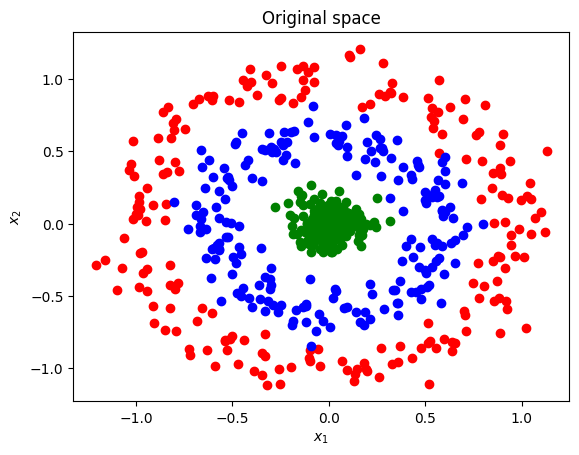

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt


np.random.seed(0)
X, Y = make_circles(n_samples=400, factor=.6, noise=.1)

X_c2 = 0.1*np.random.randn(200,2)
Y_c2 = 2*np.ones((200,))

X= np.vstack([X,X_c2])
Y= np.hstack([Y,Y_c2])

plt.figure()
plt.title("Original space")
reds = Y == 0
blues = Y == 1
green = Y == 2

plt.plot(X[reds, 0], X[reds, 1], "ro")
plt.plot(X[blues, 0], X[blues, 1], "bo")
plt.plot(X[green, 0], X[green, 1], "go")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

# split into a training and testing set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25)

# Normalizing the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Binarize the labels for supervised feature extraction methods
set_classes = np.unique(Y)
Y_train_bin = label_binarize(Y_train, classes=set_classes)
Y_test_bin = label_binarize(Y_test, classes=set_classes)


## 4.2 KPCA in sklearn

To extend the previous PCA feature extraction approach to its non-linear version, we can use of [KernelPCA( )](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html#sklearn.decomposition.KernelPCA) function.

To analyze the advantages of the non linear feature extraction, let's compare it with its linear version. So, let's start computing both linear and kernelized versions of PCA. Next code obtains the variables (P_train, P_test) and (P_train_k, P_test_k) which contain, respectively, the projected data of the linear PCA and the KPCA.

To start to work, let's compute a maximum of two new projected features and consider a Radial Basis Function kernel (RBF) with gamma (the kernel parameter) fixed to 1.

In [12]:
from sklearn.decomposition import PCA, KernelPCA

N_feat_max=2
gamma_value = 1 #0.001 #1000

# Learn a linear PCA of two components
# Transform the training set onto the new components: X_train -> P_train
# Transform the test set onto the new components: X_test -> P_test

pca = PCA(n_components=N_feat_max).fit(X_train)
P_train = pca.transform(X_train)
P_test = pca.transform(X_test)

# Learn a kernel PCA of two components with an RBF kernel and spread parameter gamma given above
# Transform the training set onto the new components: X_train -> P_train_k
# Transform the test set onto the new components: X_test -> P_test_k

kpca = KernelPCA(n_components=N_feat_max, kernel='rbf', gamma=gamma_value)
kpca.fit(X_train)
P_train_k = kpca.transform(X_train)
P_test_k = kpca.transform(X_test)


Now, let's evaluate the discriminatory capability of the projected data (both linear and kernelized ones) feeding with them a linear SVM and measuring its accuracy over the test data using either the linear PCA projected data or the KPCA ones.

In [13]:
# Define SVM classifier
from sklearn import svm
clf = svm.SVC(kernel='linear')


clf.fit(P_train, Y_train)
acc_tr =  clf.score(P_train, Y_train)
acc_tst = clf.score(P_test, Y_test)

clf.fit(P_train_k, Y_train)
acc_tr_k =  clf.score(P_train_k, Y_train)
acc_tst_k = clf.score(P_test_k, Y_test)

print("Linear PCA")
print("----------")
print("Accuracy training set: {0:.2f}".format(acc_tr*100))
print("Accuracy test set: {0:.2f}".format(acc_tst*100))
print("")
print("Kernel PCA")
print("----------")
print("Accuracy training set: {0:.2f}".format(acc_tr_k*100))
print("Accuracy test set: {0:.2f}".format(acc_tst_k*100))
print("")



Linear PCA
----------
Accuracy training set: 36.44
Accuracy test set: 24.00

Kernel PCA
----------
Accuracy training set: 94.89
Accuracy test set: 95.33



Finally, next code plots the projected data

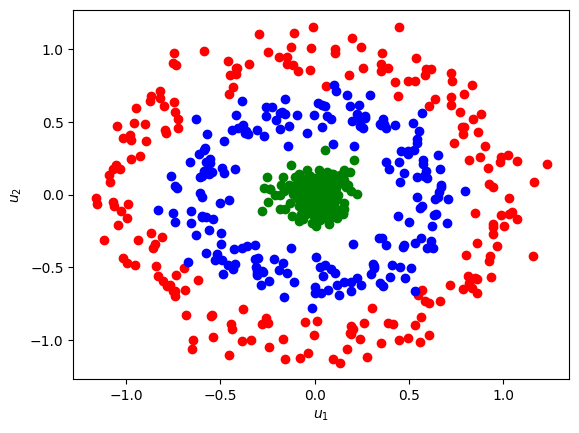

In [14]:
P_ = pca.transform(X)
Pk_=kpca.transform(X)
plt.plot(P_[reds, 0], P_[reds, 1], "ro")
plt.plot(P_[blues, 0], P_[blues, 1], "bo")
plt.plot(P_[green, 0], P_[green, 1], "go")
plt.xlabel("$u_1$")
plt.ylabel("$u_2$")
plt.show()

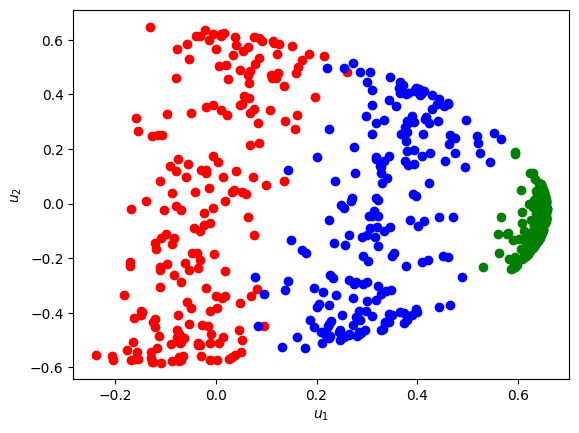

In [15]:
plt.plot(Pk_[reds, 0], Pk_[reds, 1], "ro")
plt.plot(Pk_[blues, 0], Pk_[blues, 1], "bo")
plt.plot(Pk_[green, 0], Pk_[green, 1], "go")
plt.xlabel("$u_1$")
plt.ylabel("$u_2$")
plt.show()

## 4.3 Implementation of Kernel MVA approaches

Until now, we have only used the KPCA approach because is the only not linear feature extraction method that it is included in Scikit-Learn.

However, if we compare linear and kernel versions of MVA approaches, we could extend any linear MVA approach to its kernelized version. In this way, we can use the same methods reviewed for the linear approaches and extend them to its non-linear fashion calling it with the training kernel matrix, instead of the training data, and the method would learn the dual variables, instead of the eigenvectors.

The following table relates both approaches:

|                           |        Linear             |           Kernel           |
|------                     |---------------------------|----------------------------|
|Input data                 |      ${\bf X}$            |         ${\bf K}$          |
|Variables to compute (fit) |Eigenvectors (${\bf U}$)   |Dual variables (${\bf A}$)  |
|Projection vectors         |      ${\bf U}$            |${\bf U}=\Phi^T {\bf A}$ (cannot be computed) |
|Project data (transform)   |${\bf X}' = {\bf U}^T {\bf X}^T$|${\bf X}' ={\bf  A}^T \Phi \Phi^T = {\bf  A}^T {\bf K}$|


### Computing and centering kernel matrix

Let's start this section computing the different kernel matrix that we need to train and evaluate the different feature extraction methods. For this example, we are going to consider a Radial Basis Function kernel (RBF), where each element of the kernel matrix is given by
$$k(x_i,x_j) = \exp (- \gamma (x_i -x_j)^2)$$

In particular, we need to compute two kernel matrix:
* Training data kernel matrix (`K_tr`)  where the RBF is compute pairwise over the training data. The resulting matrix dimension is of $N_{tr} \times N_{tr}$, being $N_{tr}$ the number of training data.
* Test data kernel matrix (`K_test`) where the RBF is compute between training and test samples, i.e., in RBF expression the data $x_i$ belongs to test data whereas $x_j$ belongs to training data. The resulting matrix dimension is of $N_{test} \times N_{tr}$, being $N_{test}$ and $N_{tr}$ the number of test and training data, respectively.

Let's use the [rbf_kernel( )](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.rbf_kernel.html) function to compute the `K_tr` and `K_test` kernel matrix. In this case, let's fix the kernel width value (`gamma`) to 1.

In [16]:
# Computing the kernel matrix
from sklearn.metrics.pairwise import rbf_kernel

g_value = 1

# Compute the kernel matrix (use the X_train matrix, before dividing it in validation and training data)
K_tr = rbf_kernel(X_train, gamma = g_value)
K_test  = rbf_kernel(X_test, X_train,  gamma = g_value)

After compute these kernel matrix, they have to be centered (in the same way that we remove the mean when we work over the input space). For this purpose, next code provides you the function `center_K()`  to remove the mean of both K_tr and K_test matrix.

In [17]:
def center_K(K):
    """Center a kernel matrix K, i.e., removes the data mean in the feature space.

    Args:
        K: kernel matrix
    """
    size_1,size_2 = K.shape;
    D1 = K.sum(axis=0)/size_1
    D2 = K.sum(axis=1)/size_2
    E = D2.sum(axis=0)/size_1

    K_n = K + np.tile(E,[size_1,size_2]) - np.tile(D1,[size_1,1]) - np.tile(D2,[size_2,1]).T
    return K_n


# Center the kernel matrix
K_tr_c = center_K(K_tr)
K_test_c = center_K(K_test)

### Alternative KPCA formulation


### Exercise

Design a KPCA implementation using the linear PCA function and the kernel matrix as input data.



In [18]:
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn import svm

# Defining parameters
N_feat_max = 2

## PCA method (to complete)
# 1. Train PCA with the kernel matrix and project the data
# <SOL>
pca_K2 = PCA(n_components=N_feat_max)
pca_K2.fit(K_tr_c)
P_train_k2 = pca_K2.transform(K_tr_c)
P_test_k2 = pca_K2.transform(K_test_c)
# </SOL>
# 2. Evaluate the projection performance
# <SOL>
clf = svm.SVC(kernel='linear')
clf.fit(P_train_k2, Y_train)
print('Test accuracy with PCA with a kenel matrix as input: %2.2f' %(clf.score(P_test_k2, Y_test)))
# </SOL>



Test accuracy with PCA with a kenel matrix as input: 0.95


Now, we include standard PCA implementation for comparison purposes




In [19]:
## KPCA method
# 1. Train KPCA and project the data
# Fixing gamma to 0.5 here, it is equivalent to gamma=1 in rbf function
pca_K = KernelPCA(n_components=N_feat_max, kernel="rbf", gamma=0.5)
pca_K.fit(X_train)
P_train_k = pca_K.transform(X_train)
P_test_k = pca_K.transform(X_test)

# 2. Evaluate the projection performance
clf = svm.SVC(kernel='linear')
clf.fit(P_train_k, Y_train)
print('Test accuracy with KPCA: %2.2f' %(clf.score(P_test_k, Y_test)))



Test accuracy with KPCA: 0.96


Of course, similar kernel implementations can be obtained for PLS and CCA approaches.